In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess
import sys
import darts
import torch 
import glob
from src.data_loader import load_m4_subset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
sys.path.append('..')

In [3]:
df_eda = load_m4_subset(group='Monthly', n_series=100)

# Собираем информацию о каждом ряде
series_info = []
for uid in df_eda['unique_id'].unique():
    series = df_eda[df_eda['unique_id']==uid].set_index('ds')['y']
    series_info.append({
        'uid': uid,
        'length': len(series),
        'mean': series.mean(),
        'std': series.std(),
        'min': series.min(),
        'max': series.max()
    })

info_df = pd.DataFrame(series_info)

91.7MiB [00:15, 5.75MiB/s]                           
INFO:datasetsforecast.utils:Successfully downloaded Monthly-train.csv, 91655432, bytes.
7.94MiB [00:01, 7.82MiB/s]                           
INFO:datasetsforecast.utils:Successfully downloaded Monthly-test.csv, 7942698, bytes.
4.34MiB [00:00, 8.10MiB/s]                         
INFO:datasetsforecast.utils:Successfully downloaded M4-info.csv, 4335598, bytes.
100%|██████████| 3.56M/3.56M [00:04<00:00, 785kiB/s] 
INFO:datasetsforecast.utils:Successfully downloaded submission-Naive2.zip, 3564691, bytes.
INFO:datasetsforecast.utils:Decompressing zip file...
INFO:datasetsforecast.utils:Successfully decompressed data\m4\datasets\submission-Naive2.zip


In [4]:
print("Статистика по 100 рядам:")
print(info_df.describe())

Статистика по 100 рядам:
          length         mean          std          min          max
count  100.00000   100.000000   100.000000   100.000000    100.00000
mean   305.61000  2982.358062   904.383049  1747.335290   5347.96130
std    150.57418  2876.275766  1341.780512  2037.697661   5924.63769
min     87.00000  1004.671656    76.791778   149.200000   1181.91200
25%    219.00000  1056.729085   101.673177   844.987500   1314.83850
50%    346.00000  1478.035963   277.081897   907.060500   2412.40000
75%    346.00000  3765.332294   940.363483  1615.752500   9206.64000
max    695.00000  9973.641561  7570.403956  8679.430000  33257.00000


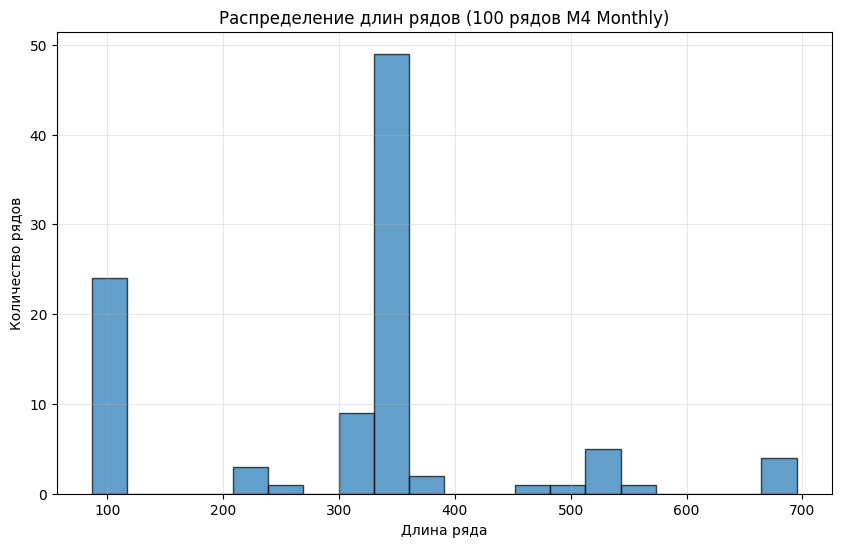

In [5]:
plt.figure(figsize=(10,6))
plt.hist(info_df['length'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение длин рядов (100 рядов M4 Monthly)')
plt.xlabel('Длина ряда')
plt.ylabel('Количество рядов')
plt.grid(True, alpha=0.3)
plt.show()

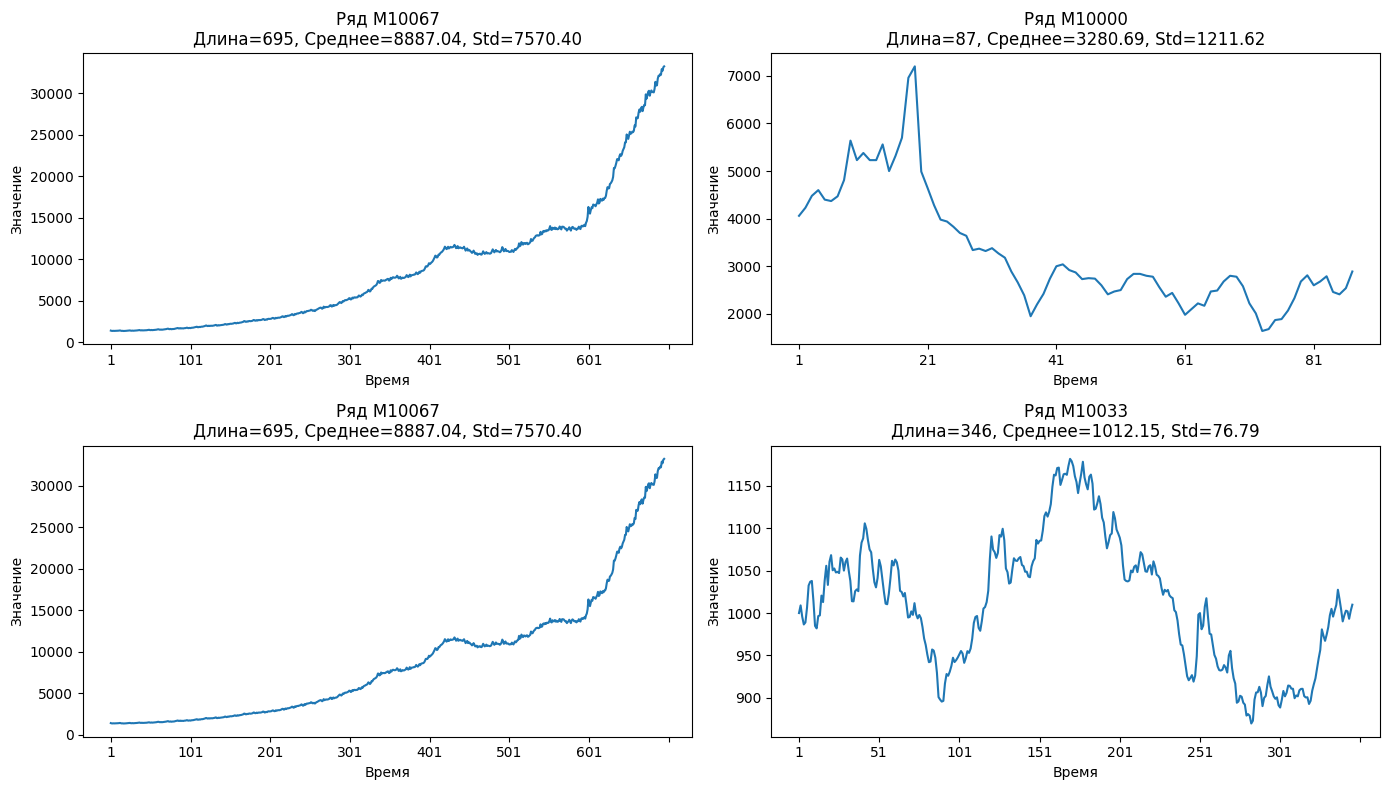

In [6]:
# Возьмём 4 ряда: самый короткий, самый длинный, с наибольшей дисперсией, с наименьшей дисперсией
uids = info_df.nlargest(1, 'length')['uid'].tolist() + \
       info_df.nsmallest(1, 'length')['uid'].tolist() + \
       info_df.nlargest(1, 'std')['uid'].tolist() + \
       info_df.nsmallest(1, 'std')['uid'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, uid in enumerate(uids):
    series = df_eda[df_eda['unique_id']==uid].set_index('ds')['y']
    ax = axes[i]
    series.plot(ax=ax)
    ax.set_title(f'Ряд {uid}\nДлина={len(series)}, Среднее={series.mean():.2f}, Std={series.std():.2f}')
    ax.set_xlabel('Время')
    ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()

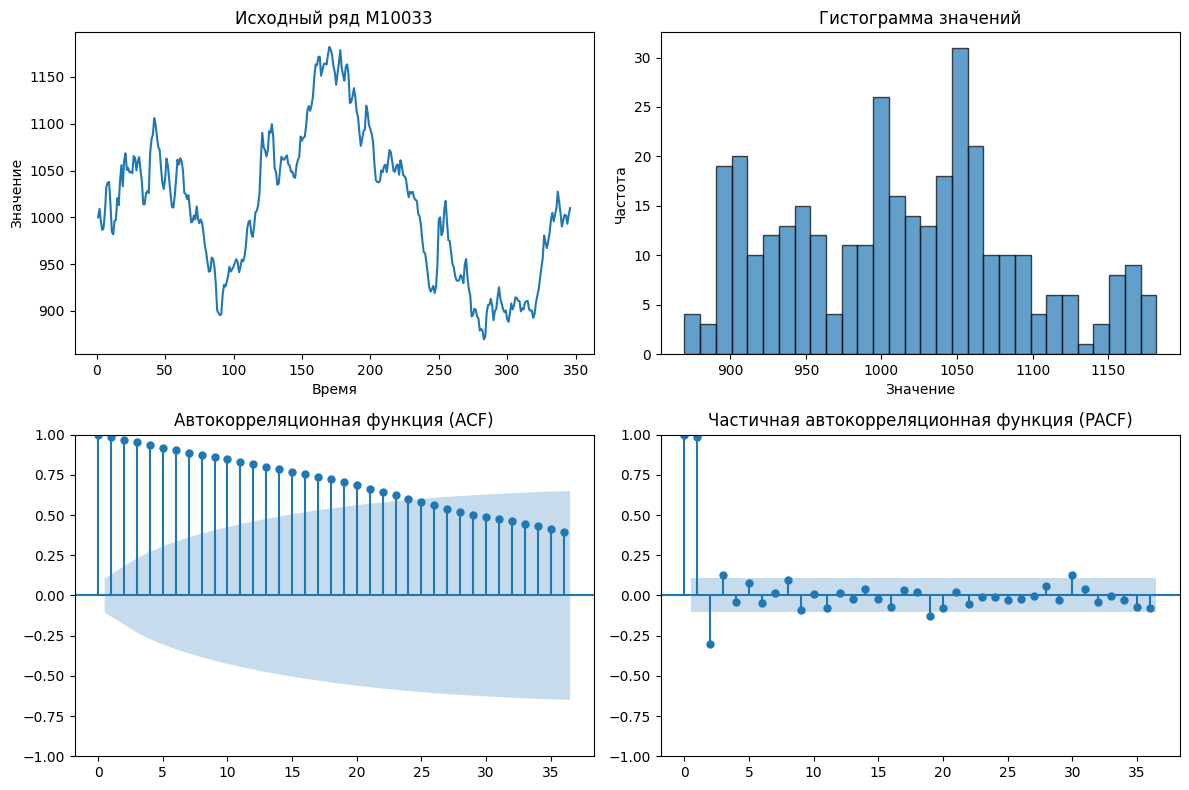

In [7]:
# Анализ сезонности и стационарности на примере одного ряда.
uid_example = info_df.sample(1)['uid'].iloc[0]
series = df_eda[df_eda['unique_id']==uid_example].set_index('ds')['y']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Исходный ряд
axes[0,0].plot(series)
axes[0,0].set_title(f'Исходный ряд {uid_example}')
axes[0,0].set_xlabel('Время')
axes[0,0].set_ylabel('Значение')

# Гистограмма распределения
axes[0,1].hist(series, bins=30, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Гистограмма значений')
axes[0,1].set_xlabel('Значение')
axes[0,1].set_ylabel('Частота')

# ACF
plot_acf(series, lags=36, ax=axes[1,0])
axes[1,0].set_title('Автокорреляционная функция (ACF)')

# PACF
plot_pacf(series, lags=36, ax=axes[1,1])
axes[1,1].set_title('Частичная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

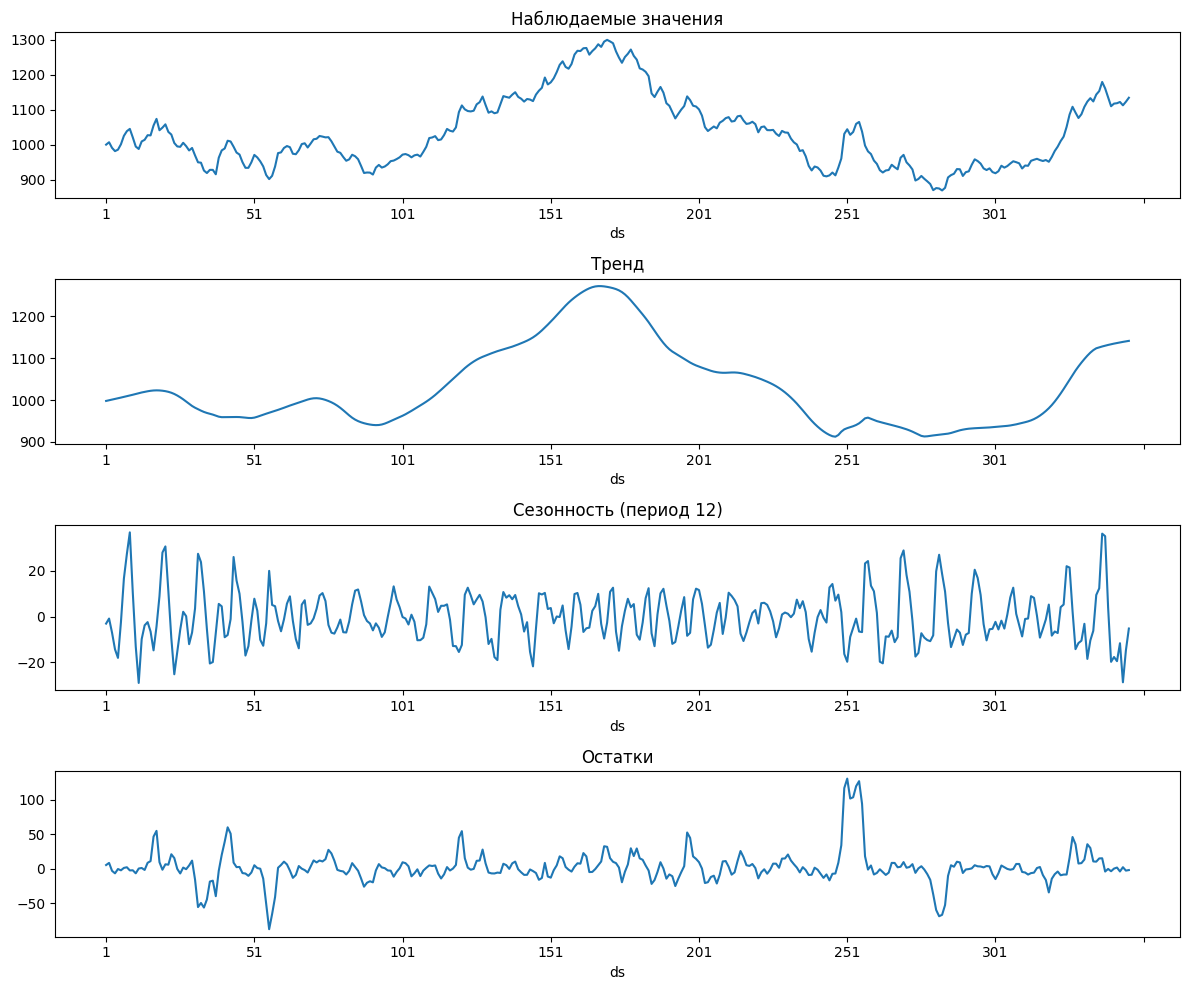

In [8]:
# Разложение ряда на компоненты тренд, сезонность, остатки

long_series = info_df[info_df['length'] >= 36].sample(1)['uid'].iloc[0]
series_long = df_eda[df_eda['unique_id']==long_series].set_index('ds')['y']

# Декомпозиция с помощью STL (сезонность 12)
from statsmodels.tsa.seasonal import STL
stl = STL(series_long, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
result.observed.plot(ax=axes[0])
axes[0].set_title('Наблюдаемые значения')
result.trend.plot(ax=axes[1])
axes[1].set_title('Тренд')
result.seasonal.plot(ax=axes[2])
axes[2].set_title('Сезонность (период 12)')
result.resid.plot(ax=axes[3])
axes[3].set_title('Остатки')
plt.tight_layout()
plt.show()

Среднее количество выбросов на ряд: 2.44
Максимальное количество выбросов: 37


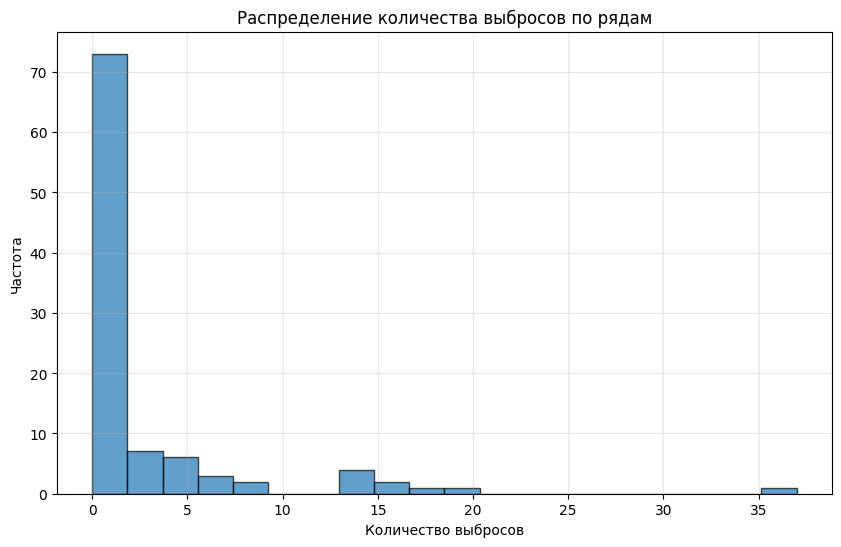

In [9]:
# Проверка на наличие выбросов 
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outliers_count = []
for uid in df_eda['unique_id'].unique():
    series = df_eda[df_eda['unique_id']==uid].set_index('ds')['y']
    outliers_count.append(count_outliers(series))

print(f"Среднее количество выбросов на ряд: {np.mean(outliers_count):.2f}")
print(f"Максимальное количество выбросов: {np.max(outliers_count)}")

# Гистограмма количества выбросов
plt.figure(figsize=(10,6))
plt.hist(outliers_count, bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение количества выбросов по рядам')
plt.xlabel('Количество выбросов')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

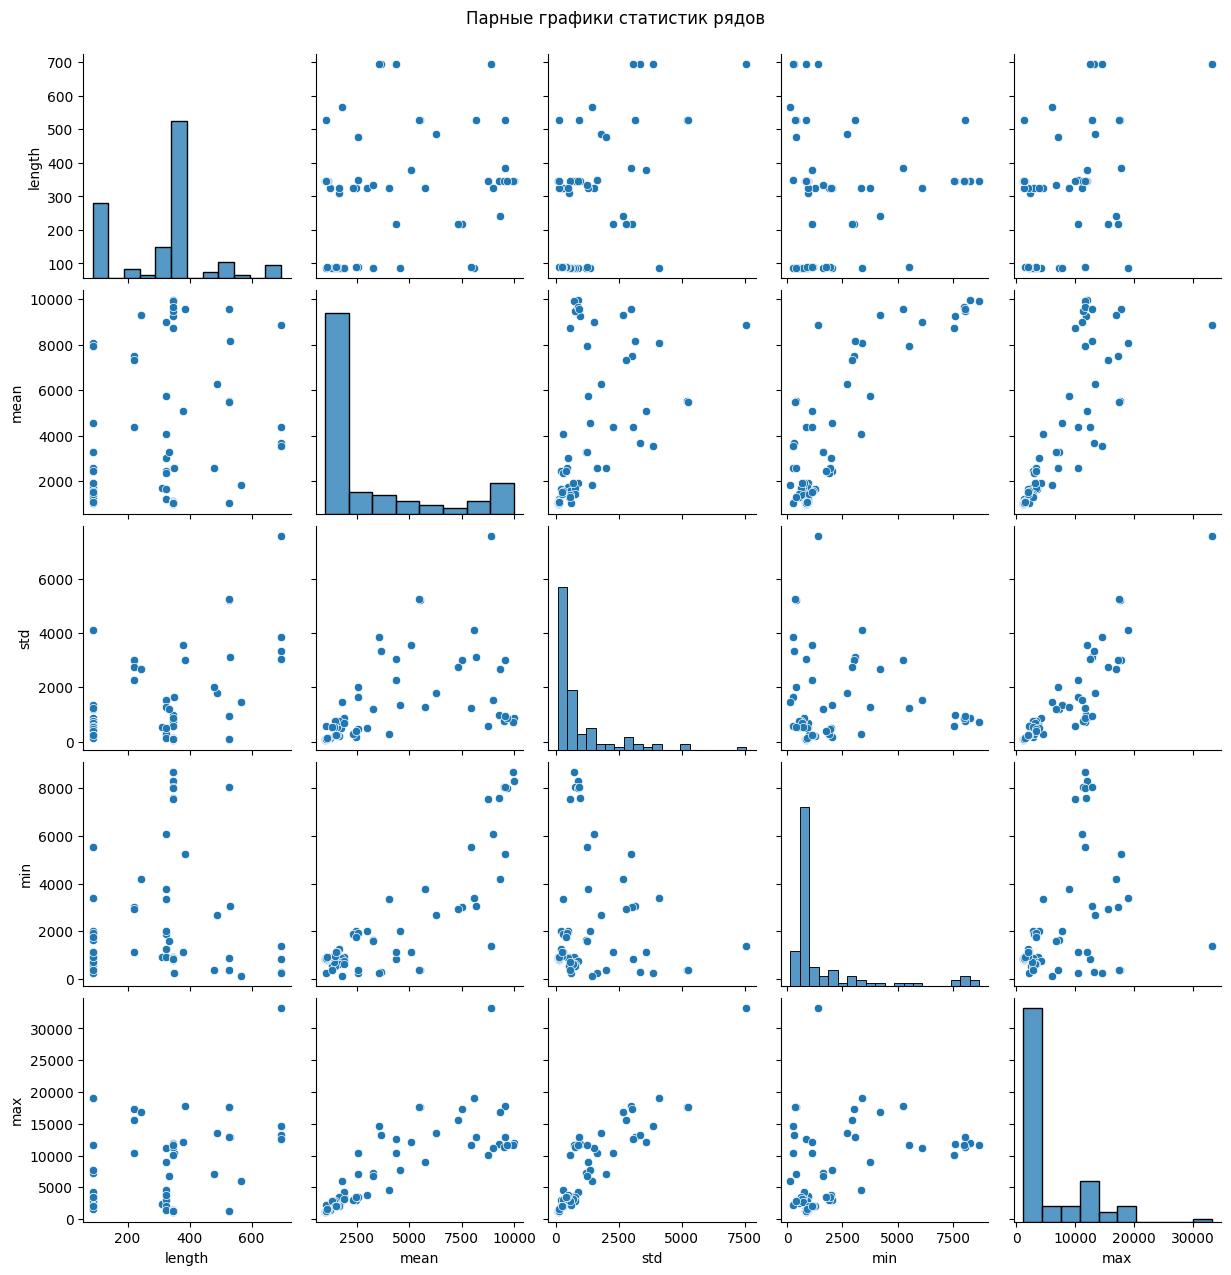

In [10]:
#Корреляция между статистиками Посмотрим, связаны ли длина ряда и дисперсия.
sns.pairplot(info_df[['length', 'mean', 'std', 'min', 'max']])
plt.suptitle('Парные графики статистик рядов', y=1.02)
plt.show()

Результаты:


,Unnamed: 1,standard,robust,quantile
naive,28.370349,28.370349,28.370349,28.370349
seasonal_naive,15.465423,15.465423,15.465423,15.465423
theta,15.428984,15.429021,15.429022,15.032485
ets,13.534582,10.374428,10.374412,12.071754
catboost,15.227850,15.244704,15.210270,15.596815
nbeats,19.361816,15.465887,16.522734,16.430916


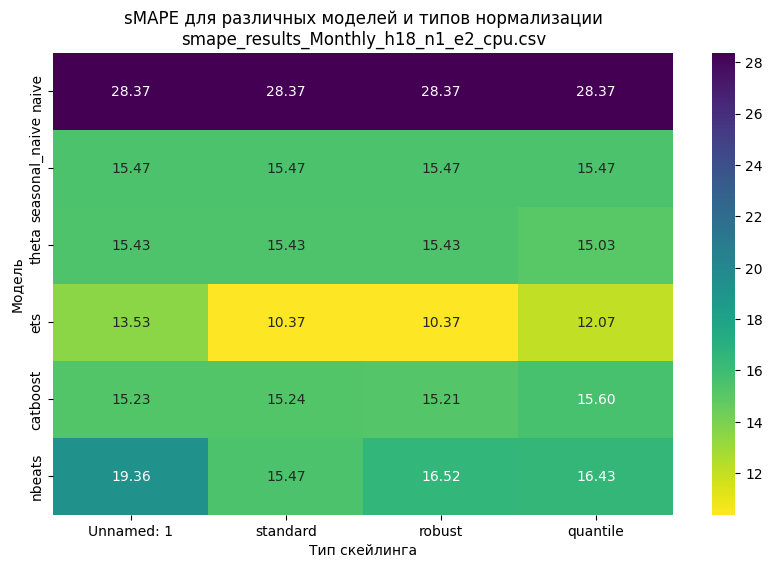

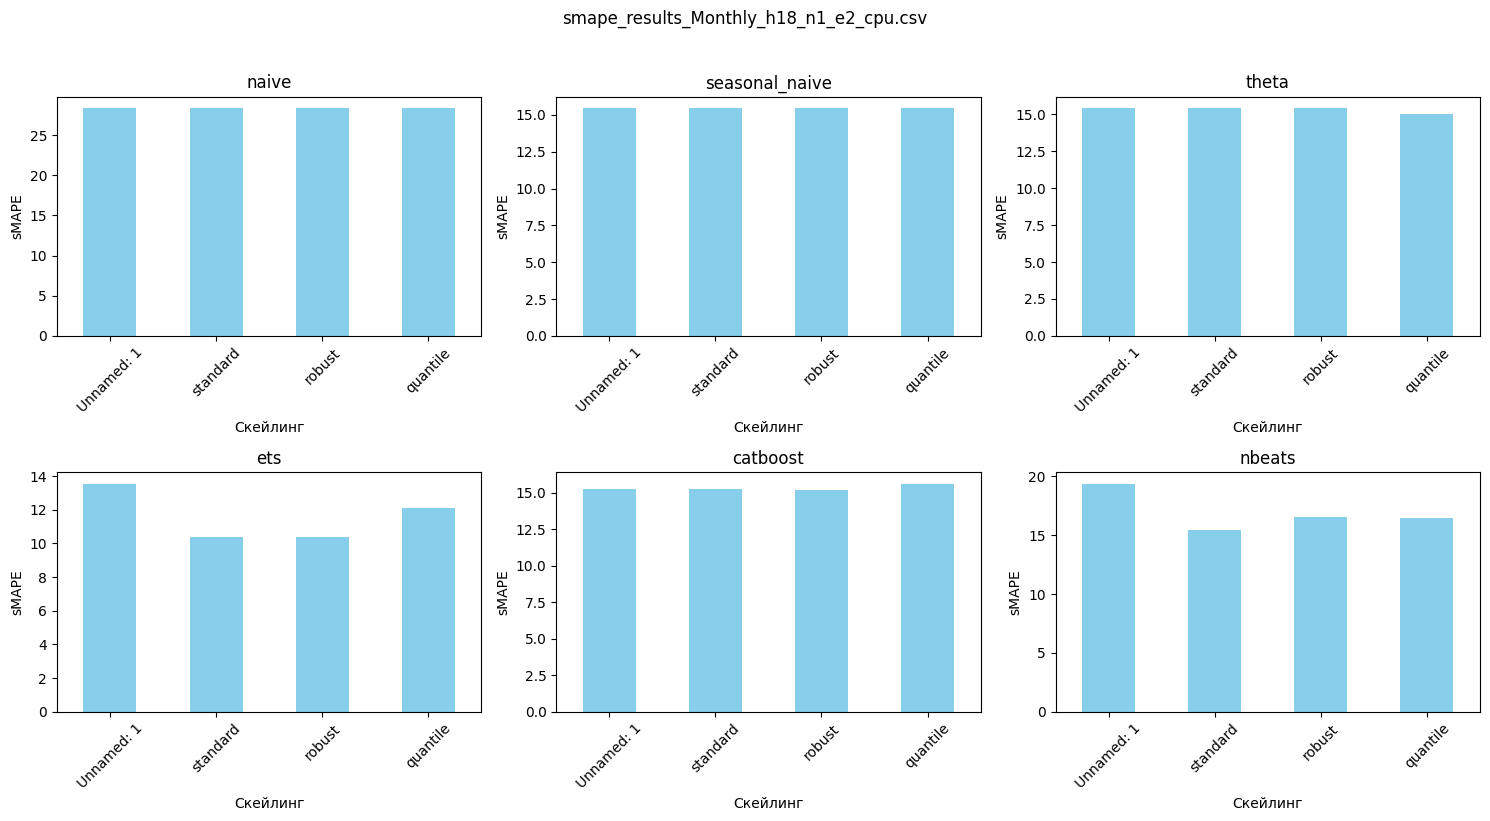

<Figure size 800x500 with 0 Axes>

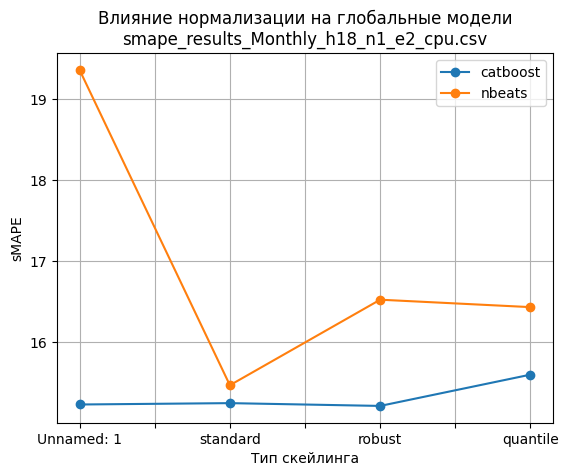

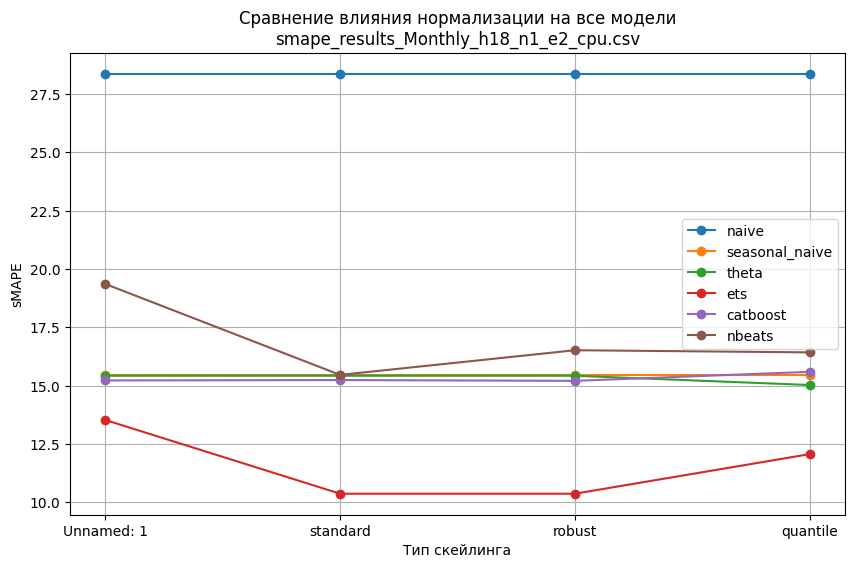


Стабильность моделей (среднее и стандартное отклонение по типам скейлинга):


,mean,std
ets,11.59,1.52
catboost,15.32,0.19
theta,15.33,0.20
seasonal_naive,15.47,0.00
nbeats,16.95,1.68
naive,28.37,0.00


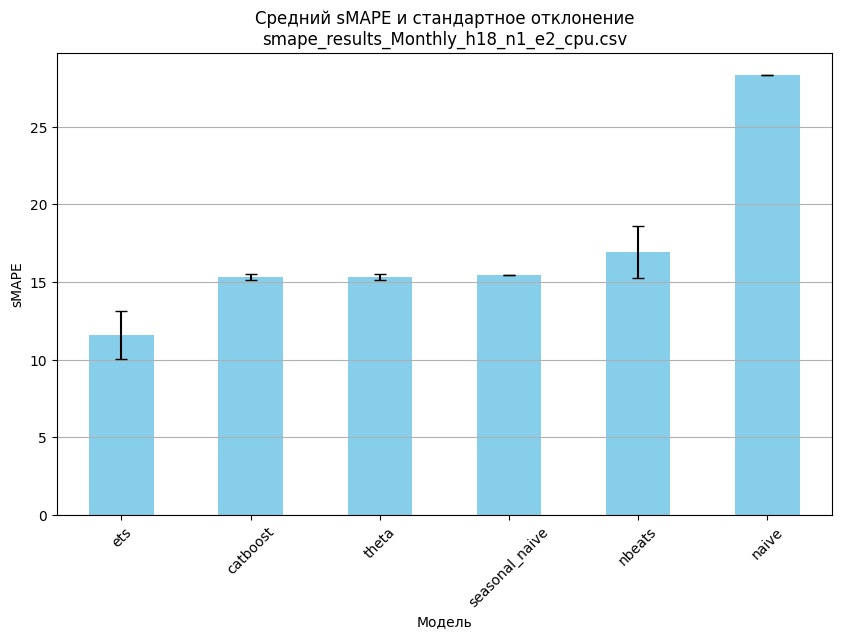

Результаты:


,Unnamed: 1,standard,robust,quantile
naive,8.922356,8.922356,8.922356,8.922356
seasonal_naive,10.577445,10.577445,10.577445,10.577445
theta,6.737191,6.737193,6.737193,7.228848
ets,7.020748,6.759284,6.766841,7.565123
catboost,8.095492,7.885449,7.350873,10.000275
nbeats,7.270208,7.684221,7.153934,9.690424


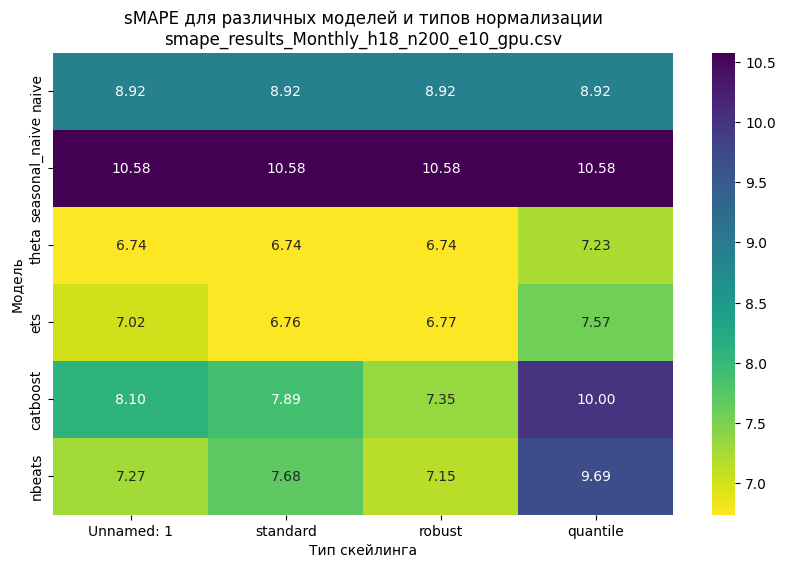

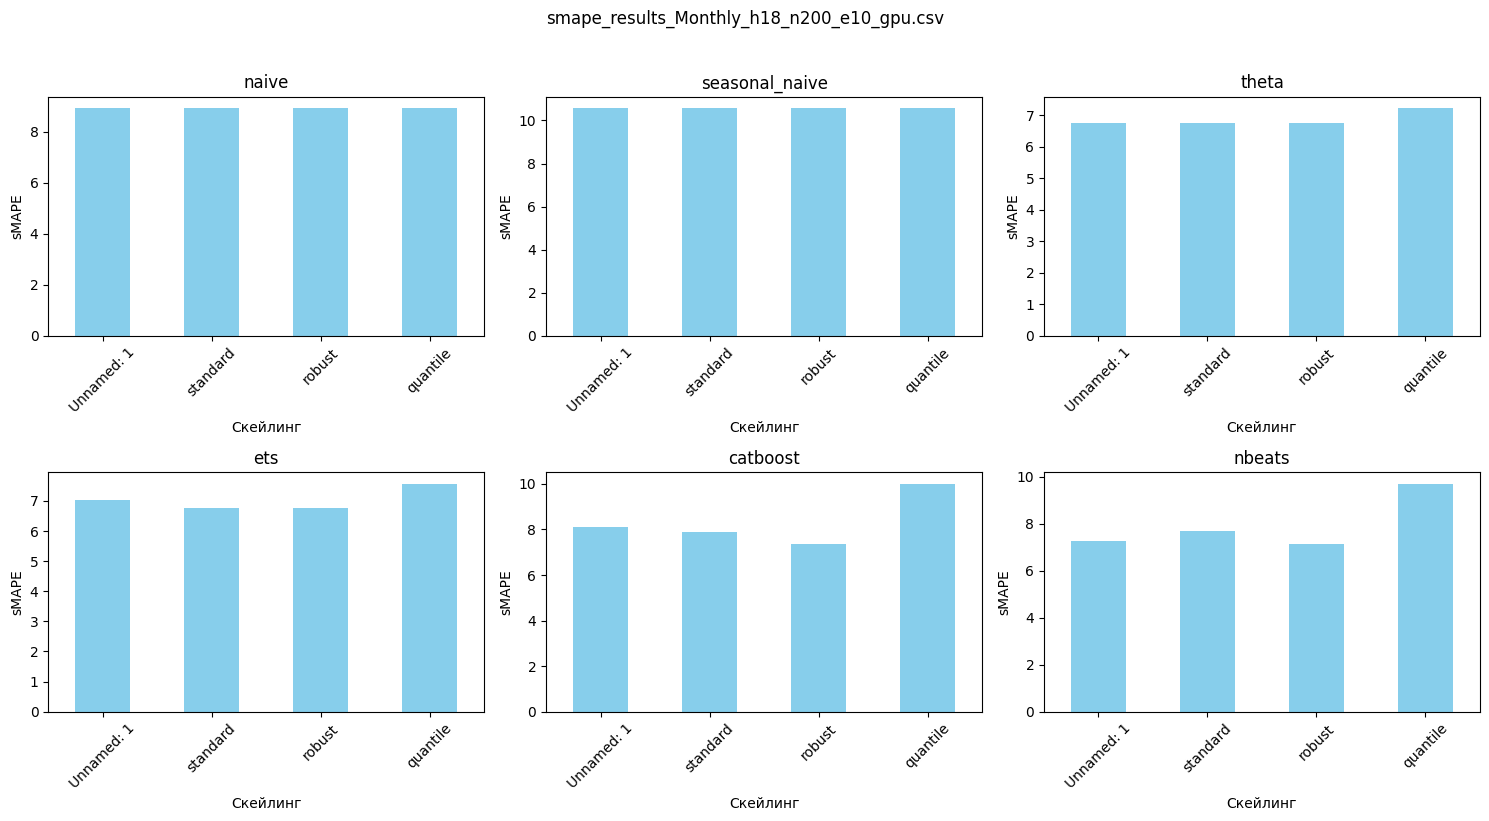

<Figure size 800x500 with 0 Axes>

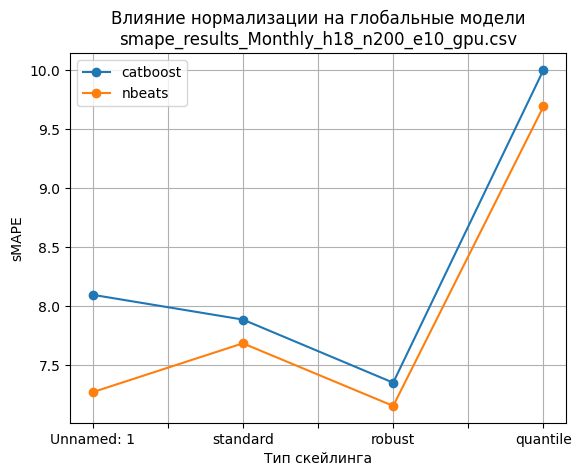

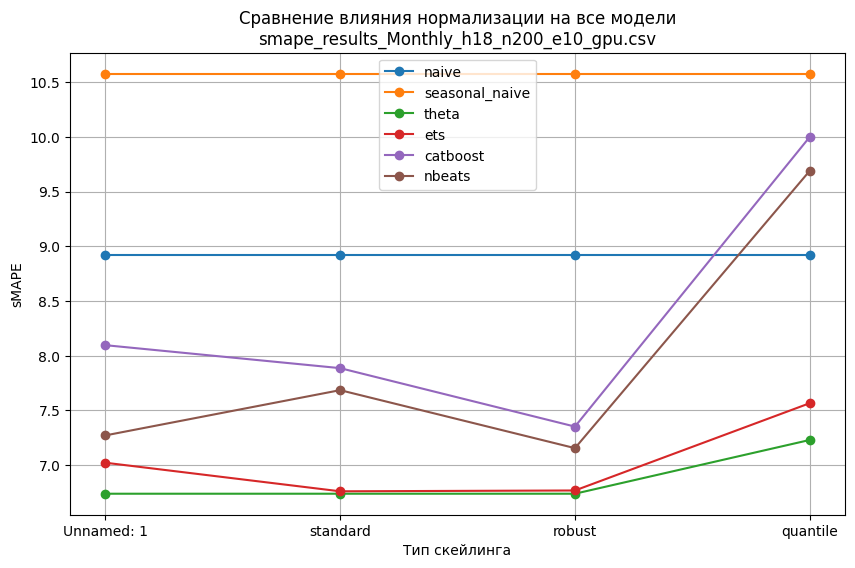


Стабильность моделей (среднее и стандартное отклонение по типам скейлинга):


,mean,std
theta,6.86,0.25
ets,7.03,0.38
nbeats,7.95,1.18
catboost,8.33,1.15
naive,8.92,0.00
seasonal_naive,10.58,0.00


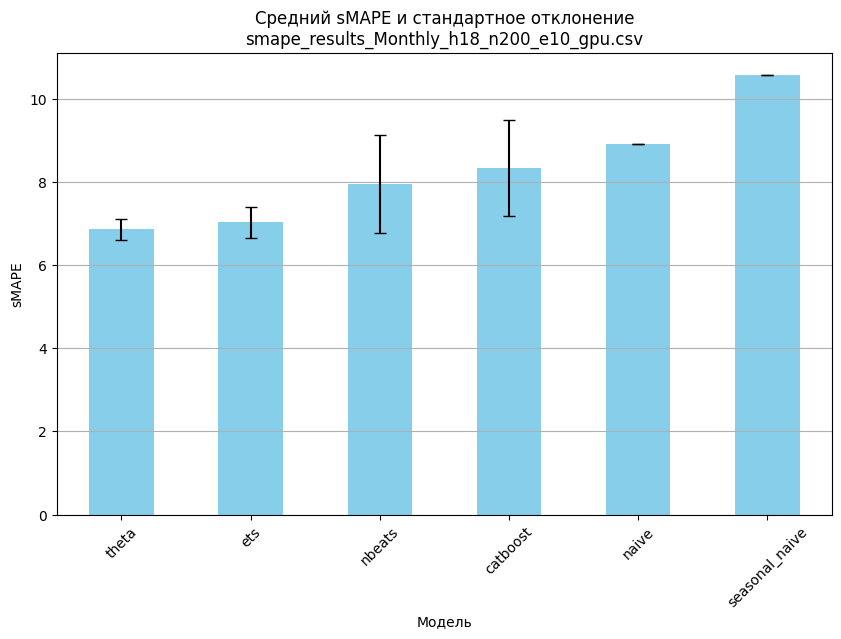

Результаты:


,Unnamed: 1,standard,robust,quantile
naive,8.922356,8.922356,8.922356,8.922356
seasonal_naive,10.577445,10.577445,10.577445,10.577445
theta,6.737191,6.737193,6.737193,7.228848
ets,7.020748,6.759284,6.766841,7.565123
catboost,8.094060,7.874488,7.351092,10.011408
nbeats,7.659170,7.934636,7.435273,10.078990


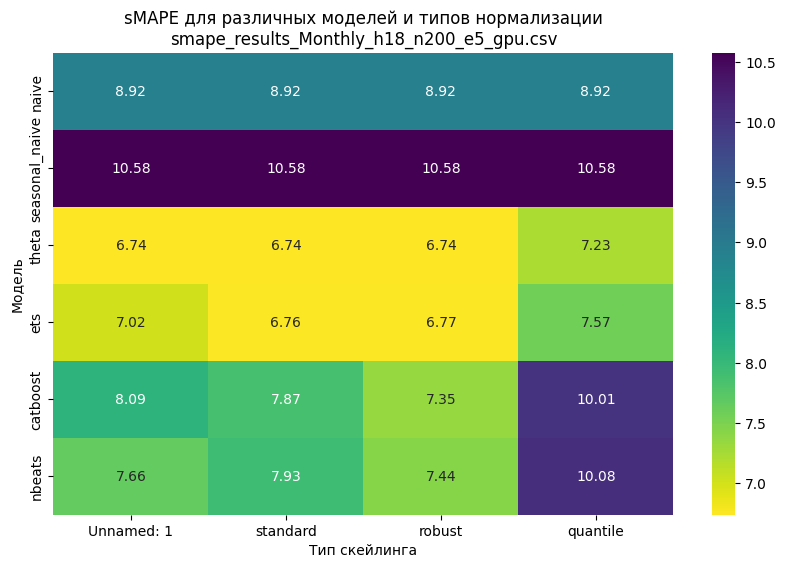

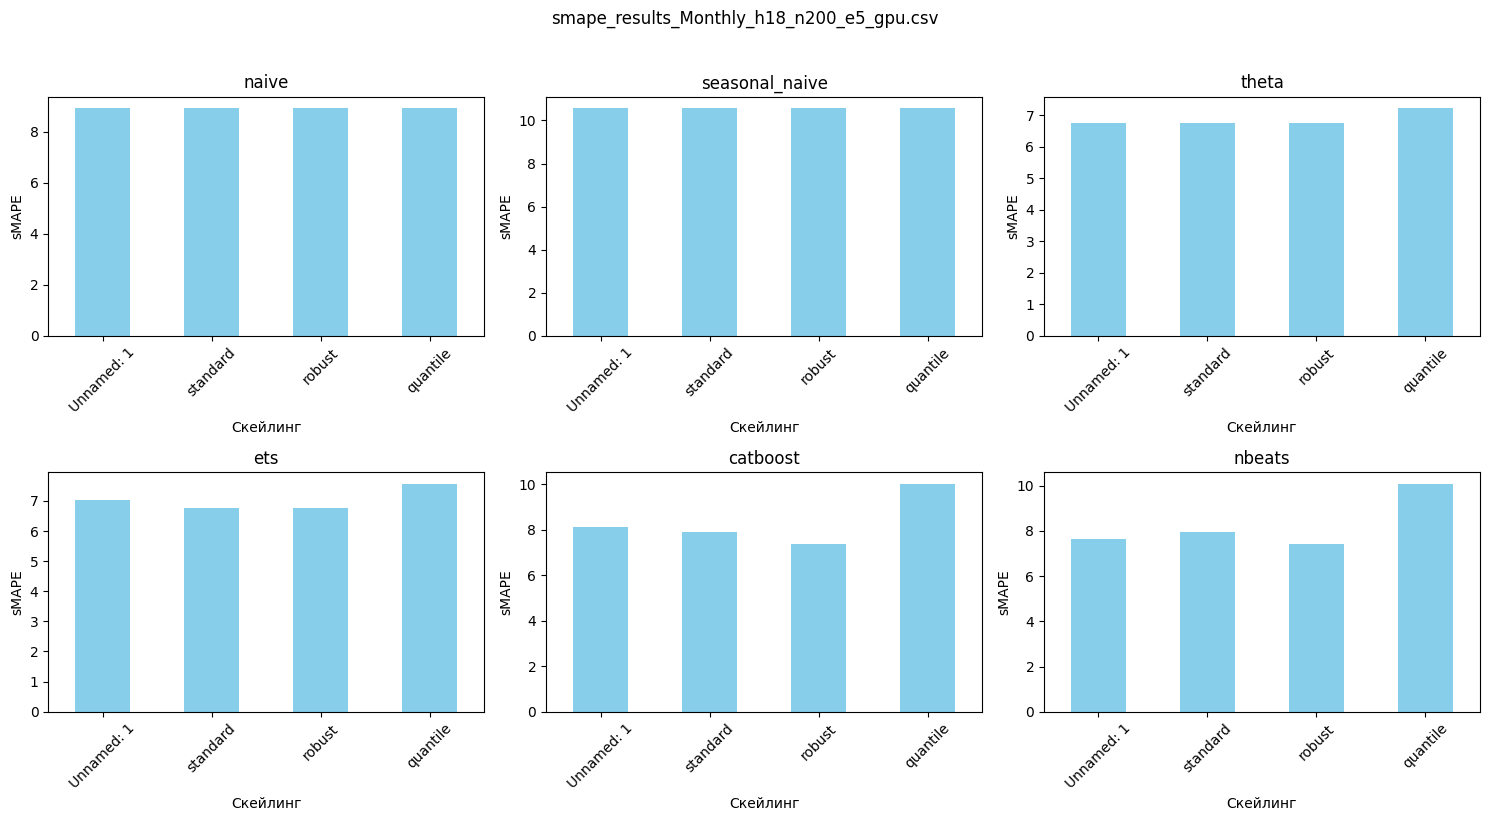

<Figure size 800x500 with 0 Axes>

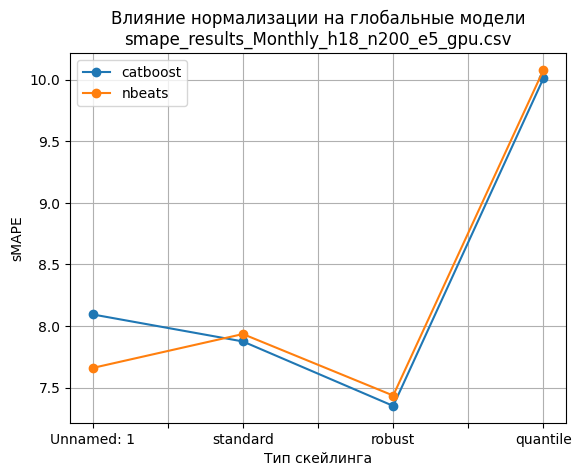

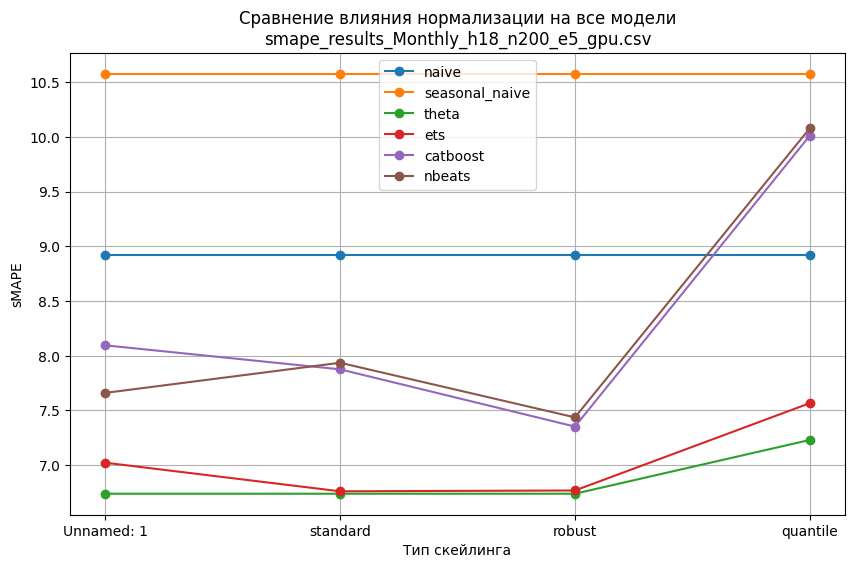


Стабильность моделей (среднее и стандартное отклонение по типам скейлинга):


,mean,std
theta,6.86,0.25
ets,7.03,0.38
nbeats,8.28,1.22
catboost,8.33,1.16
naive,8.92,0.00
seasonal_naive,10.58,0.00


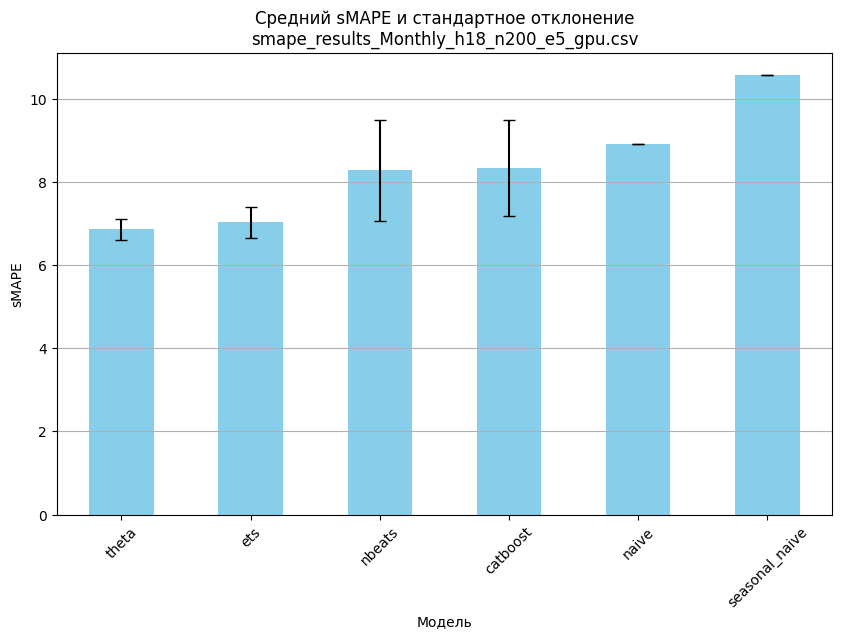

Результаты:


,Unnamed: 1,standard,robust,quantile
naive,11.294118,11.294118,11.294118,11.294118
seasonal_naive,10.401891,10.401891,10.401891,10.401891
theta,5.788748,5.788796,5.788794,11.445778
ets,11.740735,7.478808,7.479122,13.502445
catboost,24.595203,24.595203,24.595203,17.312073
nbeats,25.887600,22.536532,26.558313,23.995078


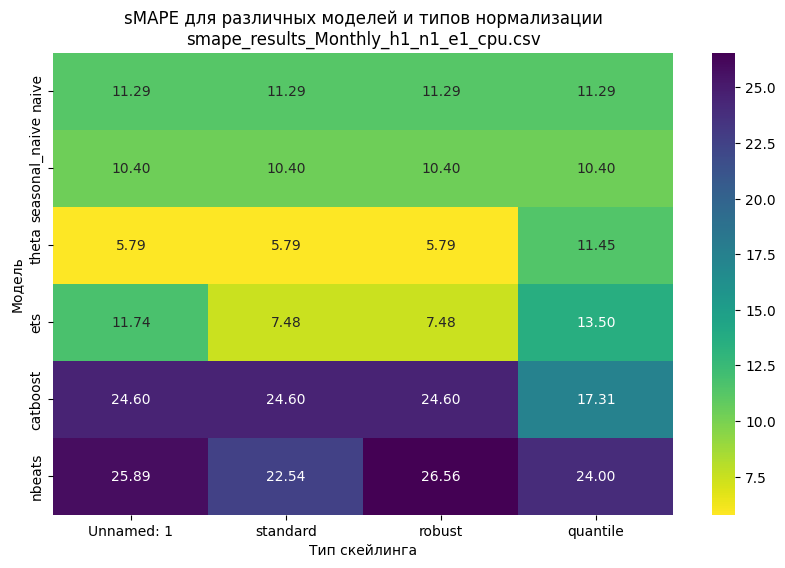

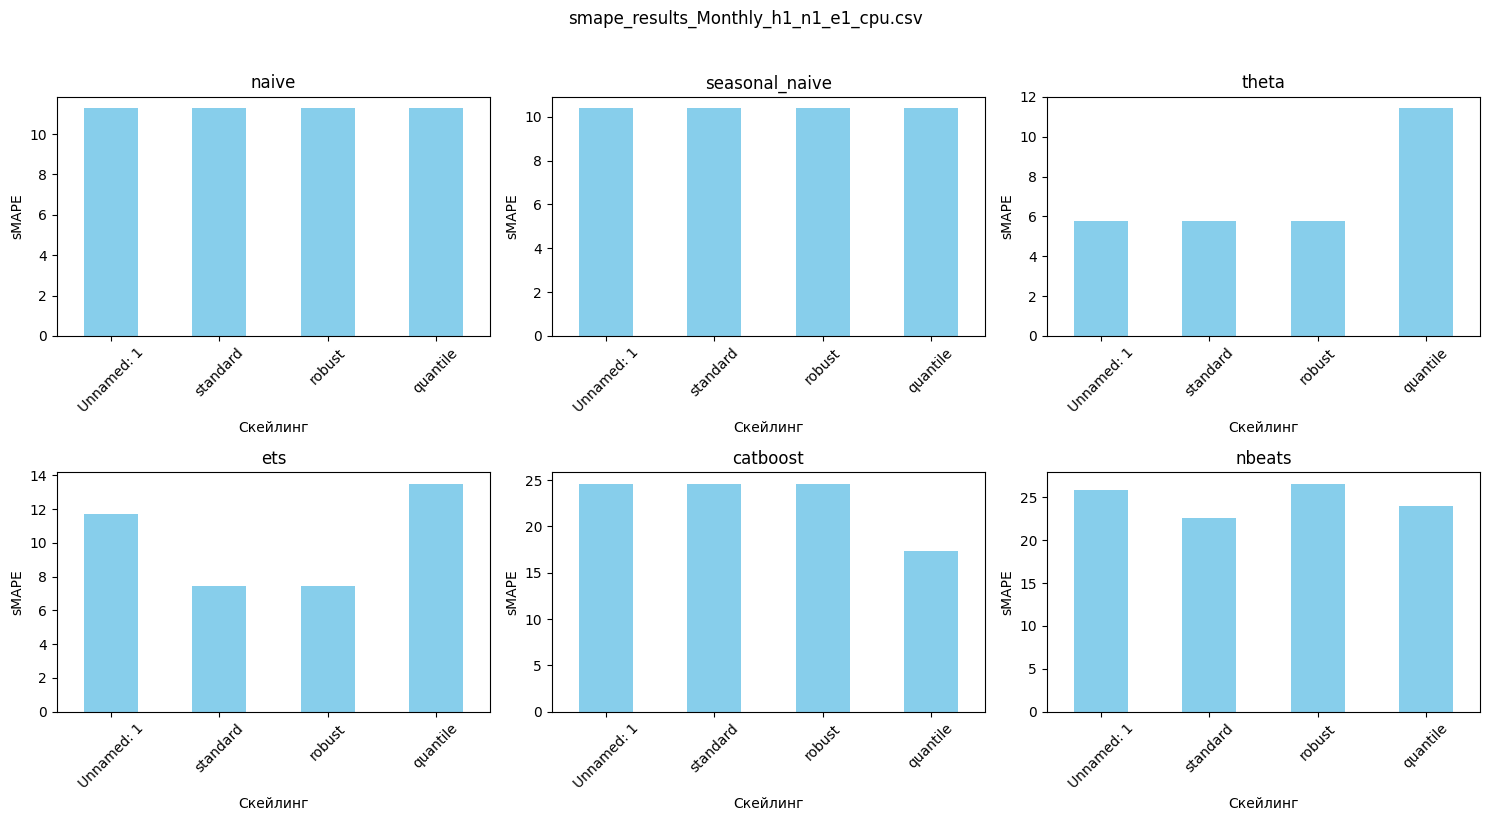

<Figure size 800x500 with 0 Axes>

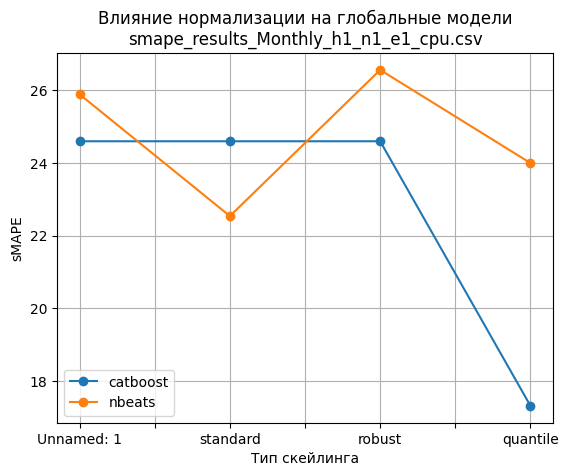

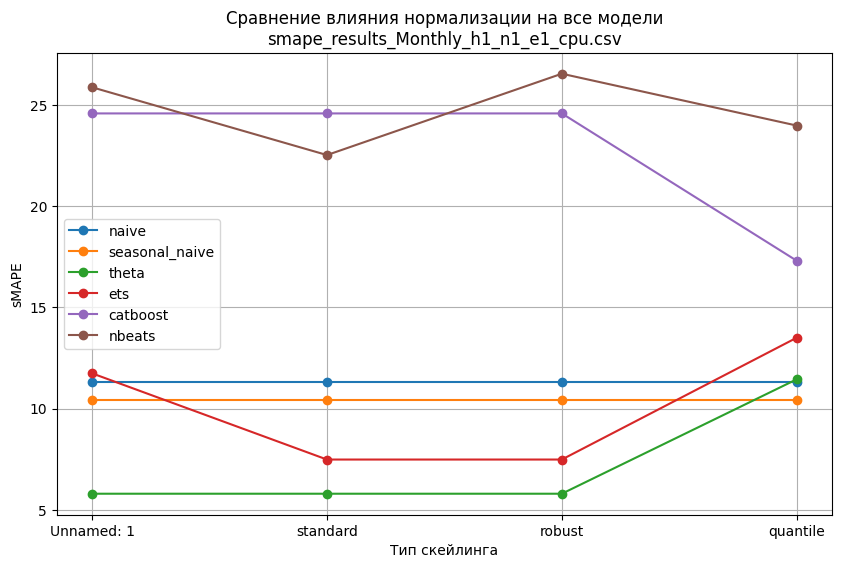


Стабильность моделей (среднее и стандартное отклонение по типам скейлинга):


,mean,std
theta,7.20,2.83
ets,10.05,3.05
seasonal_naive,10.40,0.00
naive,11.29,0.00
catboost,22.77,3.64
nbeats,24.74,1.83


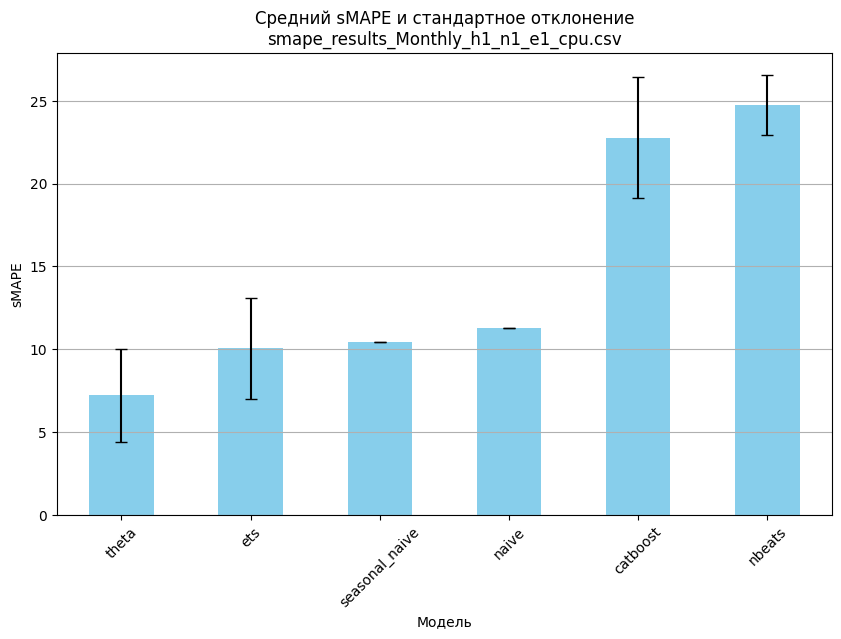

Результаты:


,Unnamed: 1,standard,robust,quantile
naive,11.294118,11.294118,11.294118,11.294118
seasonal_naive,10.401891,10.401891,10.401891,10.401891
theta,5.788792,5.788796,5.788794,11.445777
ets,10.380189,8.137944,8.027113,13.053613
catboost,18.553290,18.553215,18.553212,18.152811
nbeats,1.810909,30.377431,1.676039,27.712137


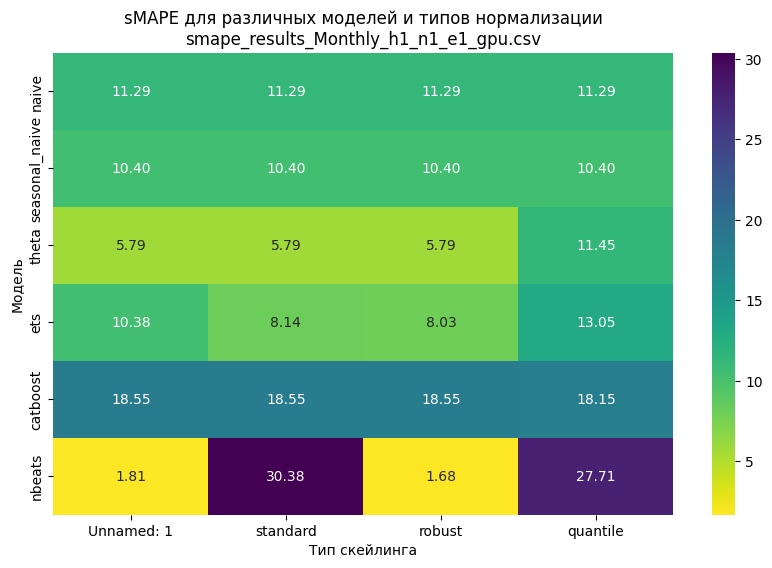

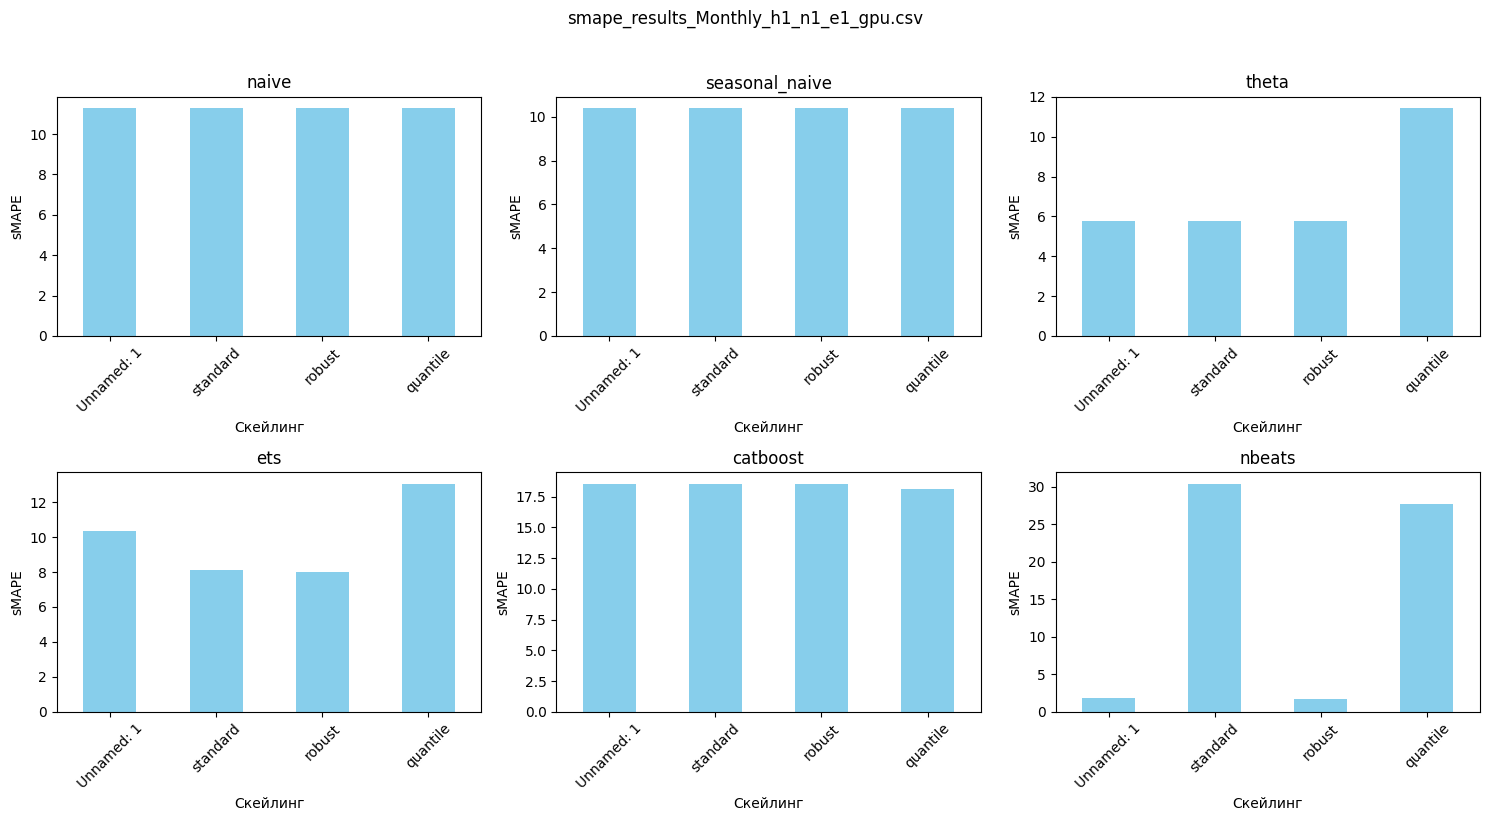

<Figure size 800x500 with 0 Axes>

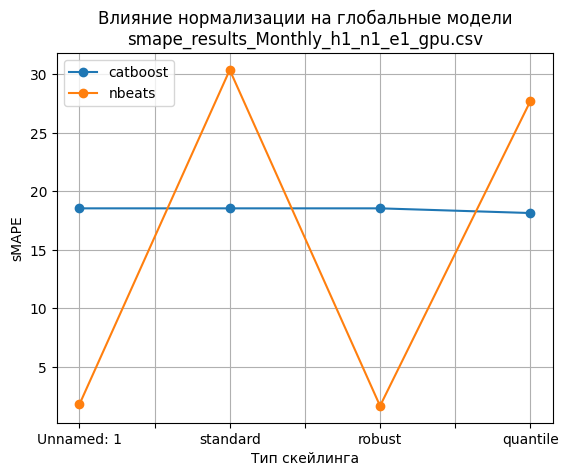

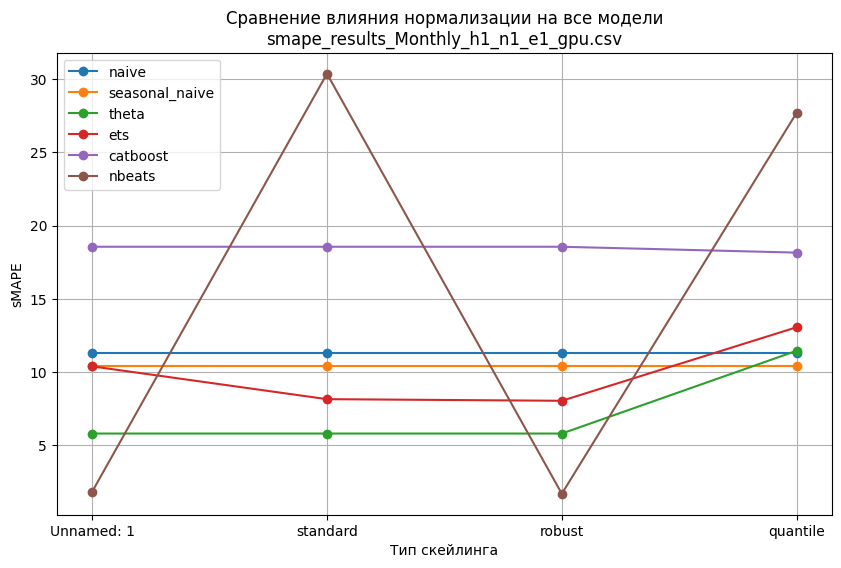


Стабильность моделей (среднее и стандартное отклонение по типам скейлинга):


,mean,std
theta,7.20,2.83
ets,9.90,2.37
seasonal_naive,10.40,0.00
naive,11.29,0.00
nbeats,15.39,15.80
catboost,18.45,0.20


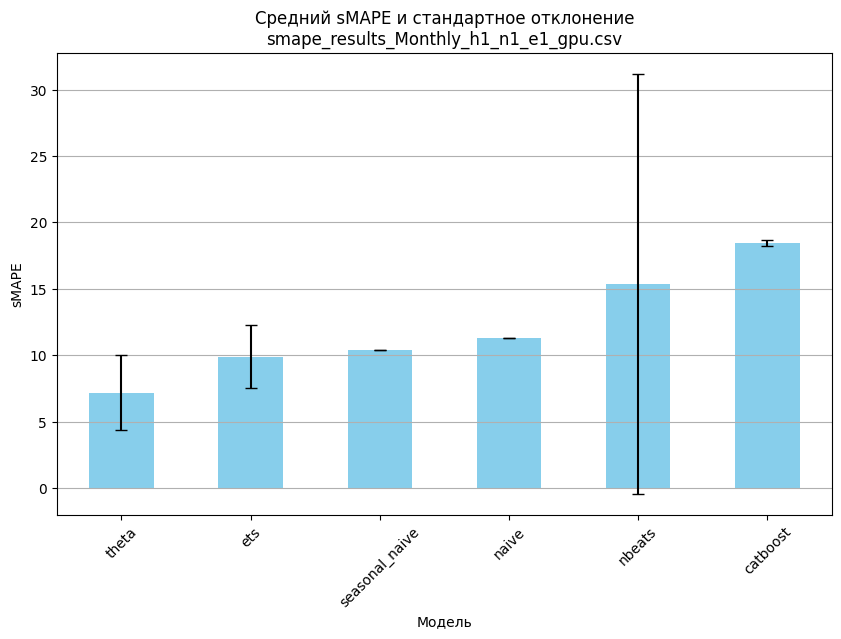

In [13]:
# Поиск файлов с результатами
if os.path.exists('results'):
    search_path = 'results/*.csv'
else:
    search_path = '*.csv'

files = glob.glob(search_path)
files = [f for f in files if 'smape_results_' in os.path.basename(f)]

if len(files) == 0:
    print("Файлы с результатами не найдены.")
else:
    for file_idx, file_path in enumerate(files):
        file_name = os.path.basename(file_path)
        
        # Загрузка данных
        df = pd.read_csv(file_path, index_col=0)
        print("Результаты:")
        display(df)
        
        #Тепловая карта
        plt.figure(figsize=(10,6))
        sns.heatmap(df, annot=True, fmt='.2f', cmap='viridis_r')
        plt.title(f'sMAPE для различных моделей и типов нормализации\n{file_name}')
        plt.xlabel('Тип скейлинга')
        plt.ylabel('Модель')
        plt.show()
        
        #Столбчатые диаграммы для каждой модели
        fig, axes = plt.subplots(2, 3, figsize=(15,8))
        axes = axes.flatten()
        for i, model in enumerate(df.index):
            ax = axes[i]
            df.loc[model].plot(kind='bar', ax=ax, color='skyblue')
            ax.set_title(model)
            ax.set_ylabel('sMAPE')
            ax.set_xlabel('Скейлинг')
            ax.tick_params(axis='x', rotation=45)
        plt.suptitle(file_name, y=1.02)
        plt.tight_layout()
        plt.show()
        
        #Сравнение глобальных моделей CatBoost и N‑BEATS
        plt.figure(figsize=(8,5))
        if 'catboost' in df.index and 'nbeats' in df.index:
            df.loc[['catboost', 'nbeats']].T.plot(marker='o')
        else:
            # На случай если названия отличаются (например, 'nbeats' отсутствует)
            models_to_plot = [m for m in ['catboost', 'nbeats'] if m in df.index]
            if models_to_plot:
                df.loc[models_to_plot].T.plot(marker='o')
        plt.title(f'Влияние нормализации на глобальные модели\n{file_name}')
        plt.ylabel('sMAPE')
        plt.xlabel('Тип скейлинга')
        plt.grid(True)
        plt.show()
        
        #Точечный график для всех моделей
        plt.figure(figsize=(10,6))
        for model in df.index:
            plt.plot(df.columns, df.loc[model], marker='o', label=model)
        plt.xlabel('Тип скейлинга')
        plt.ylabel('sMAPE')
        plt.title(f'Сравнение влияния нормализации на все модели\n{file_name}')
        plt.legend()
        plt.grid(True)
        plt.show()
        
        #Статистика стабильности (среднее и std)
        stats = pd.DataFrame({
            'mean': df.mean(axis=1),
            'std': df.std(axis=1)
        }).sort_values('mean')
        print("\nСтабильность моделей (среднее и стандартное отклонение по типам скейлинга):")
        display(stats.round(2))
        
        #Столбчатая диаграмма стабильности
        plt.figure(figsize=(10,6))
        stats['mean'].plot(kind='bar', yerr=stats['std'], capsize=4, color='skyblue')
        plt.title(f'Средний sMAPE и стандартное отклонение\n{file_name}')
        plt.ylabel('sMAPE')
        plt.xlabel('Модель')
        plt.xticks(rotation=45)
        plt.grid(axis='y')
        plt.show()
        
